Downloading by ucimlrepo

In [2]:
!pip install -q ucimlrepo scikit-learn imbalanced-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, hamming_loss, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

RNG = 42
LABELS = ["Family", "Genus", "Species"]

(a)Load data 70/30

In [3]:
from google.colab import drive
drive.mount('/content/drive')

CSV = "/content/drive/My Drive/USC_Summer26/EE559/Data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv"
df = pd.read_csv(CSV)
print(df.shape)
print(df[LABELS].nunique())

feature_cols = [c for c in df.columns if c.startswith("MFCCs_")]
X = df[feature_cols].values
Y = df[LABELS].copy()

encoders = {L: LabelEncoder().fit(Y[L]) for L in LABELS}
Y_enc = np.column_stack([encoders[L].transform(Y[L]) for L in LABELS])

X_tr, X_te, Y_tr, Y_te = train_test_split(
    X, Y_enc, test_size=0.30, random_state=RNG, stratify=Y_enc[:, 2]
)
print("train:", X_tr.shape, " test:", X_te.shape)

Mounted at /content/drive
(7195, 26)
Family      4
Genus       8
Species    10
dtype: int64
train: (5036, 22)  test: (2159, 22)


(b)i

In [4]:
def exact_match(Yt, Yp):
    return np.mean(np.all(Yt == Yp, axis=1))

def hamming_score(Yt, Yp):
    return np.mean(Yt == Yp)

def report_multilabel(Yt, Yp, tag=""):
    em, hs = exact_match(Yt, Yp), hamming_score(Yt, Yp)
    print(f"[{tag}]  Exact match = {em:.4f} | Hamming score = {hs:.4f} | Hamming loss = {1-hs:.4f}")
    for j, L in enumerate(LABELS):
        print(f"     {L:8s} acc = {accuracy_score(Yt[:, j], Yp[:, j]):.4f}")
    return em, hs, 1 - hs

results = {}

(b)ii

In [6]:
C_range     = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-4, 2, 7)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)

def train_ova(Xtr, Ytr, Xte, normalize=True, penalty_l1=False):
    if normalize:
        sc = StandardScaler().fit(Xtr)
        Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    preds, best = np.zeros((Xte.shape[0], 3), dtype=int), {}
    for j, L in enumerate(LABELS):
        if penalty_l1:
            base, grid = LinearSVC(penalty="l1", dual=False, max_iter=5000), {"C": C_range}
        else:
            base = SVC(kernel="rbf", decision_function_shape="ovr")
            grid = {"C": C_range, "gamma": gamma_range}
        gs = GridSearchCV(base, grid, cv=cv, scoring="accuracy", n_jobs=-1).fit(Xtr, Ytr[:, j])
        preds[:, j], best[L] = gs.predict(Xte), gs.best_params_
        print(f"     {L:8s} best={gs.best_params_}  CV acc={gs.best_score_:.4f}")
    return preds, best

print("(b)ii  RBF SVM (NORMALIZED)")
pred_norm, best_norm = train_ova(X_tr, Y_tr, X_te, normalize=True)
results["RBF normalized"] = report_multilabel(Y_te, pred_norm, "RBF normalized")

print("\n (b)ii  RBF SVM (RAW)")
pred_raw, best_raw = train_ova(X_tr, Y_tr, X_te, normalize=False)
results["RBF raw"] = report_multilabel(Y_te, pred_raw, "RBF raw")

(b)ii  RBF SVM (NORMALIZED)
     Family   best={'C': np.float64(100.0), 'gamma': np.float64(0.01)}  CV acc=0.9899
     Genus    best={'C': np.float64(100.0), 'gamma': np.float64(0.01)}  CV acc=0.9865
     Species  best={'C': np.float64(100.0), 'gamma': np.float64(0.01)}  CV acc=0.9869
[RBF normalized]  Exact match = 0.9866 | Hamming score = 0.9910 | Hamming loss = 0.0090
     Family   acc = 0.9931
     Genus    acc = 0.9898
     Species  acc = 0.9903

 (b)ii  RBF SVM (RAW)
     Family   best={'C': np.float64(10.0), 'gamma': np.float64(1.0)}  CV acc=0.9915
     Genus    best={'C': np.float64(10.0), 'gamma': np.float64(1.0)}  CV acc=0.9885
     Species  best={'C': np.float64(10.0), 'gamma': np.float64(1.0)}  CV acc=0.9873
[RBF raw]  Exact match = 0.9875 | Hamming score = 0.9921 | Hamming loss = 0.0079
     Family   acc = 0.9926
     Genus    acc = 0.9921
     Species  acc = 0.9917


(b)iii

In [7]:
print("b)iii  L1-penalized linear SVM (NORMALIZED)")
pred_l1, best_l1 = train_ova(X_tr, Y_tr, X_te, normalize=True, penalty_l1=True)
results["L1 linear"] = report_multilabel(Y_te, pred_l1, "L1 linear")

b)iii  L1-penalized linear SVM (NORMALIZED)
     Family   best={'C': np.float64(1.0)}  CV acc=0.9343
     Genus    best={'C': np.float64(100.0)}  CV acc=0.9533
     Species  best={'C': np.float64(100.0)}  CV acc=0.9573
[L1 linear]  Exact match = 0.9171 | Hamming score = 0.9494 | Hamming loss = 0.0506
     Family   acc = 0.9393
     Genus    acc = 0.9491
     Species  acc = 0.9597


(b)iv

In [9]:
def train_l1_smote(Xtr, Ytr, Xte):
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    preds = np.zeros((Xte.shape[0], 3), dtype=int)
    for j, L in enumerate(LABELS):
        cnt = np.bincount(Ytr[:, j])
        k = max(1, min(5, cnt[cnt > 0].min() - 1))       # guard tiny classes
        Xr, yr = SMOTE(random_state=RNG, k_neighbors=k).fit_resample(Xtr_s, Ytr[:, j])
        gs = GridSearchCV(LinearSVC(penalty="l1", dual=False, max_iter=5000),
                          {"C": C_range}, cv=cv, scoring="accuracy", n_jobs=-1).fit(Xr, yr)
        preds[:, j] = gs.predict(Xte_s)
        print(f"     {L:8s} best={gs.best_params_}  CV acc={gs.best_score_:.4f}  n={len(yr)}")
    return preds

print("(b)iv  L1 linear SVM + SMOTE (NORMALIZED)")
pred_smote = train_l1_smote(X_tr, Y_tr, X_te)
results["L1 + SMOTE"] = report_multilabel(Y_te, pred_smote, "L1 + SMOTE")

(b)iv  L1 linear SVM + SMOTE (NORMALIZED)
     Family   best={'C': np.float64(10.0)}  CV acc=0.9450  n=12372
     Genus    best={'C': np.float64(10.0)}  CV acc=0.9513  n=23232
     Species  best={'C': np.float64(10.0)}  CV acc=0.9534  n=24340
[L1 + SMOTE]  Exact match = 0.8601 | Hamming score = 0.9301 | Hamming loss = 0.0699
     Family   acc = 0.9148
     Genus    acc = 0.9166
     Species  acc = 0.9588


(b)v

In [10]:
sc = StandardScaler().fit(X_tr)
Xtr_s, Xte_s = sc.transform(X_tr), sc.transform(X_te)

C_best     = best_norm["Species"]["C"]
gamma_best = best_norm["Species"]["gamma"]

chain = ClassifierChain(SVC(kernel="rbf", C=C_best, gamma=gamma_best),
                        order=[0, 1, 2], random_state=RNG).fit(Xtr_s, Y_tr)
pred_chain = chain.predict(Xte_s).astype(int)
results["Classifier Chain"] = report_multilabel(Y_te, pred_chain, "Classifier Chain")

[Classifier Chain]  Exact match = 0.9893 | Hamming score = 0.9907 | Hamming loss = 0.0093
     Family   acc = 0.9931
     Genus    acc = 0.9898
     Species  acc = 0.9893


(b)vi


 RBF normalized 

 Family 
[[  19    0    0    1]
 [   0  163    0    0]
 [   1    0  642    6]
 [   1    0    6 1320]]
                 precision    recall  f1-score   support

      Bufonidae       0.90      0.95      0.93        20
  Dendrobatidae       1.00      1.00      1.00       163
        Hylidae       0.99      0.99      0.99       649
Leptodactylidae       0.99      0.99      0.99      1327

       accuracy                           0.99      2159
      macro avg       0.97      0.98      0.98      2159
   weighted avg       0.99      0.99      0.99      2159


 Genus 
[[1243    0    1    1    0    1    0    0]
 [   0  163    0    0    0    0    0    0]
 [   2    0   91    0    0    0    0    0]
 [   4    0    0  472    2    0    0    0]
 [   0    0    0    2   79    0    0    0]
 [   1    0    0    5    0   28    0    0]
 [   1    0    0    0    1    0   18    0]
 [   0    0    1    0    0    0    0   43]]
               precision    recall  f1-score   support

    Adenom

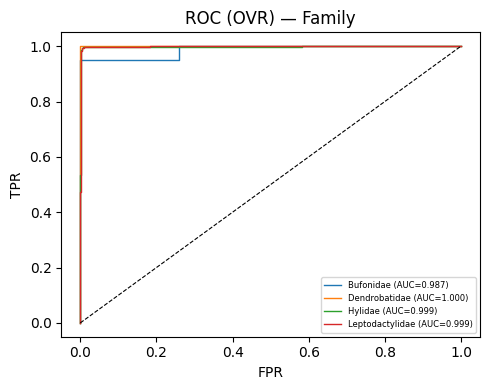

Genus: macro AUC = 0.9969 | micro AUC = 0.9993


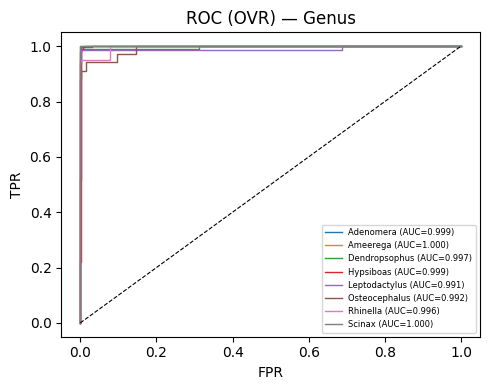

Species: macro AUC = 0.9985 | micro AUC = 0.9996


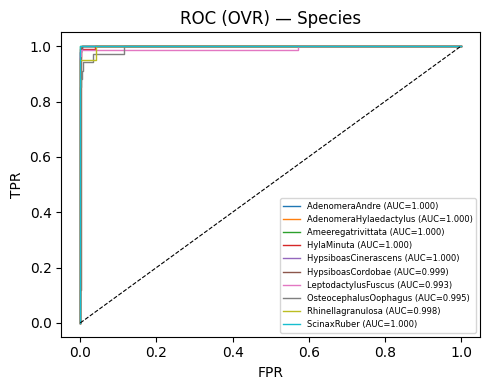

In [11]:
def full_metrics(Yt, Yp, tag):
    print(f"\n {tag} ")
    for j, L in enumerate(LABELS):
        print(f"\n {L} ")
        print(confusion_matrix(Yt[:, j], Yp[:, j]))
        print(classification_report(Yt[:, j], Yp[:, j],
                                    target_names=encoders[L].classes_, zero_division=0))

full_metrics(Y_te, pred_norm, "RBF normalized")

for j, L in enumerate(LABELS):
    clf = SVC(kernel="rbf", C=best_norm[L]["C"], gamma=best_norm[L]["gamma"],
              probability=True, random_state=RNG).fit(Xtr_s, Y_tr[:, j])
    proba = clf.predict_proba(Xte_s)
    classes = np.unique(Y_tr[:, j])
    y_bin = label_binarize(Y_te[:, j], classes=classes)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    print(f"{L}: macro AUC = {roc_auc_score(y_bin, proba, multi_class='ovr', average='macro'):.4f} | "
          f"micro AUC = {roc_auc_score(y_bin.ravel(), proba.ravel()):.4f}")

    plt.figure(figsize=(5, 4))
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        plt.plot(fpr, tpr, lw=1, label=f"{encoders[L].classes_[c]} (AUC={auc(fpr,tpr):.3f})")
    plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC (OVR) — {L}")
    plt.legend(fontsize=6); plt.tight_layout(); plt.show()

Summary

In [12]:
summary = pd.DataFrame(results, index=["Exact match", "Hamming score", "Hamming loss"]).T
print(summary.round(4).to_string())

                  Exact match  Hamming score  Hamming loss
RBF normalized         0.9866         0.9910        0.0090
RBF raw                0.9875         0.9921        0.0079
L1 linear              0.9171         0.9494        0.0506
L1 + SMOTE             0.8601         0.9301        0.0699
Classifier Chain       0.9893         0.9907        0.0093

LaTeX:
 \begin{tabular}{lrrr}
\toprule
 & Exact match & Hamming score & Hamming loss \\
\midrule
RBF normalized & 0.986600 & 0.991000 & 0.009000 \\
RBF raw & 0.987500 & 0.992100 & 0.007900 \\
L1 linear & 0.917100 & 0.949400 & 0.050600 \\
L1 + SMOTE & 0.860100 & 0.930100 & 0.069900 \\
Classifier Chain & 0.989300 & 0.990700 & 0.009300 \\
\bottomrule
\end{tabular}

